In [1]:
import glob
import re
import os

import numpy as np
from pathlib import Path

from pymor.basic import *
from pymor.core.pickle import load

from RBInvParam.problems.elasticity.build import build_InstationaryModelIP

set_log_levels({
    'pymor' : 'WARN'
})

set_defaults({})


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

fontsize = 14
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "cm",
    "font.size": fontsize,
    #'text.latex.preamble': r'\usepackage{amsfonts} \usepackage{accents}',
    'figure.dpi': 200
})

Exception in thread Control:
Traceback (most recent call last):
  File "/home/dealii/workdir/venv/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/dealii/workdir/venv/lib/python3.10/site-packages/ipykernel/kernelbase.py", line 339, in dispatch_control
    await self.process_control(msg)
  File "/home/dealii/workdir/venv/lib/python3.10/site-packages/ipykernel/kernelbase.py", line 352, in process_control
    self.log.debug("Control received: %s", msg)
  File "/usr/lib/python3.10/logging/__init__.py", line 1465, in debug
    self._log(DEBUG, msg, args, **kwargs)
  File "/usr/lib/python3.10/logging/__init__.py", line 1624, in _log
    self.handle(record)
  File "/usr/lib/python3.10/logging/__init__.py", line 1634, in handle
    self.callHandlers(record)
  File "/usr/lib/python3.10/logging/__init__.py", line 1696, in callHandlers
    hdlr.handle(record)
  File "/usr/lib/python3.10/logging/__init__.py", line 968, in handle
    sel

In [3]:
from typing import Dict, Tuple, Optional

def get_last_file(path: Path) -> Path | None:
    # --- Step 1: Look for final files first ---
    final_candidates = [
        path / "TR_IRGNM_final.pkl",
        path / "FOM_IRGNM_final.pkl"
    ]
    
    for final_file in final_candidates:
        if final_file.exists():
            return final_file.name  # Return immediately if found
    
    # --- Step 2: If no final file exists, find the highest index file ---
    files = glob.glob(os.path.join(path, "TR_IRGNM_*.pkl"))
    files += glob.glob(os.path.join(path, "FOM_IRGNM_*.pkl"))

    indexed_files = []
    for f in files:
        match = re.search(r'(?:TR|FOM)_IRGNM_(\d+)\.pkl$', os.path.basename(f))
        if match:
            idx = int(match.group(1))
            indexed_files.append((idx, f))

    if indexed_files:
        _, max_file = max(indexed_files, key=lambda x: x[0])
        return Path(max_file).name

    print("No matching IRGNM result files found.")
    return None

def filter_and_reorder(d: Dict, pattern: str = r'.*FOM.*') -> Tuple[Dict, Optional[str]]:
    regex = re.compile(pattern)
    matching = [k for k in d if regex.search(k)]
    non_matching = [k for k in d if k not in matching]

    # Sort keys alphabetically within each group
    non_matching_sorted = sorted(non_matching)
    matching_sorted = sorted(matching)

    # Build the reordered dict: alphabetically sorted non-matching first, then matching ones
    reordered = {k: d[k] for k in non_matching_sorted}
    reordered.update({k: d[k] for k in matching_sorted})

    # Return reordered dict and the single matching key (if exactly one match)
    if len(matching_sorted) == 1:
        return reordered, matching_sorted[0]
    else:
        return reordered, None

In [4]:
#SAVE_PATH = Path('/home/dealii/workdir/figs')
#SAVE_PATH = Path('/home/benedikt/Schreibtisch/error_stagnation')
SAVE_PATH = Path('./workbench')

########################################################################################

#WORK_DIR = Path('/home/benedikt/Dokumente/parabolische_inverse_probleme/experiments')
WORK_DIR = Path('/home/dealii/workdir/experiments')
#WORK_DIR = Path('/home/benedikt/Dokumente/parabolische_inverse_probleme/experiments')

subset = 'new_baseline'
obs_op = 'sensors'
data_dir_path = WORK_DIR / 'new_pre_paper_version' / 'new_baseline_tau_1.50'

experiment_names = []
pattern = re.compile(rf'^{subset}_.*_{obs_op}.*')

experiment_names += [
    d.name for d in data_dir_path.iterdir()
    if d.is_dir() and pattern.match(d.name)
]

data_paths = [data_dir_path / experiment_name for experiment_name in experiment_names]
file_names = [get_last_file(data_path) for data_path in data_paths]

########################################################################################

#data_dir_path = Path('/home/dealii/workdir/examples/elasticity/dumps') / '20251201_121655_TR_IRGNM'
# data_dir_path = Path('/home/benedikt/Dokumente/parabolische_inverse_probleme/examples/elasticity/dumps') / '20251208_094842_TR_IRGNM'

# experiment_names = []
# pattern = re.compile(rf'.*')

# experiment_names += [
#     d.name for d in data_dir_path.iterdir()
#     if d.is_dir() and pattern.match(d.name)
# ]

# data_paths = [data_dir_path]
# file_names = [get_last_file(data_path) for data_path in data_paths]

########################################################################################

setup = None
data = {}
optimizer_parameters = {}

for (data_path, file_name) in zip(data_paths, file_names):            

    try:
        with open(data_path / file_name, 'rb') as file:
            data_ = load(file)
        data[str(data_path.name)] = data_
    except TypeError:
        print(f"Can not find dumps for {data_path}")
    except:
        print(f"Can not open {data_path / file_name}")

    if not setup:
        with open(data_path / 'setup.pkl', 'rb') as file:
            setup = load(file)

    
    optimizer_parameter_path = data_path / 'optimizer_parameter.pkl'
    with open(optimizer_parameter_path, 'rb') as file:
        optimizer_parameter = load(file)
        
    optimizer_parameters[str(data_path.name)] = optimizer_parameter

data, FOM_key = filter_and_reorder(data, pattern=r'.*FOM.*')
#assert FOM_key

# if not 'FOM' in locals():
#     FOM = build_InstationaryModelIP(setup=setup)

print(data.keys())


dict_keys(['new_baseline_TR_sensors', 'new_baseline_TR_sensors_time_step', 'new_baseline_TR_sensors_time_step_full', 'new_baseline_FOM_sensors'])


In [5]:
from RBInvParam.reductor import InstationaryModelIPReductor

FOM = build_InstationaryModelIP(setup=setup)
reductor = InstationaryModelIPReductor(
    FOM,
    optimizer_parameter['error_estimator_types'],
    use_adjoint_space = optimizer_parameter["use_adjoint_space"],
    parallel = optimizer_parameter["offline_parallel"]
)

[2025-12-19 12:15:56,925][build_InstationaryModelIP] - Construct problem..
	 Setting up BC constraints.
	 Setting up system matrizies.
	 Using CosseratDelamination SystemMatrix
	 Using CenterExcite BodyForce
	 Assembling force list.
	 ---------------------- 
	 #DoFs: 14415
	 #Parameter: 961
[2025-12-19 12:16:02,094][__init__] - Setting up InstationaryModelIP
[2025-12-19 12:16:02,095][reset_cached_operators] - Deleting cache
[2025-12-19 12:16:04,410][build_InstationaryModelIP] - noise_level is 5.0000e-05
[2025-12-19 12:16:04,411][build_InstationaryModelIP] - rel_noise_level_y = 5.1203e-03
[2025-12-19 12:16:04,411][build_InstationaryModelIP] - rel_noise_level_u = 2.7134e-05
[2025-12-19 12:16:04,424][__init__] - Setting up InstationaryModelIP
[2025-12-19 12:16:04,425][reset_cached_operators] - Deleting cache
[2025-12-19 12:16:04,426][__init__] - Setting up InstationaryModelIPReductor
[2025-12-19 12:16:04,426][__init__] - Using residual image basis mode: 'none'.


In [6]:
# data_ = data['log_errors_TR_sensors_1e-09']
# grad = FOM.compute_gradient(data_['q'][-3])
# plt.imshow(grad.to_numpy().reshape((31,31)))
# plt.colorbar() 

In [7]:
# i = -3
# d = data_['q'][i+1] - data_['q'][i]
# q_ = data_['q'][i] + d * (1/5)

In [8]:
# grad_ = FOM.compute_gradient(q_)
# plt.imshow(grad_.to_numpy().reshape((31,31)))
# plt.colorbar() 

In [9]:
from RBInvParam.reductor import InstationaryModelIPReductor
from RBInvParam.snapshot_preprocessor import SnapshotPreprocessor

import pymor_dealii_bindings as pd2

data_ = data['new_baseline_TR_sensors_time_step']
bases = ['parameter_basis', 'state_basis']

reductor = InstationaryModelIPReductor(
    FOM,
    optimizer_parameter['error_estimator_types'],
    use_adjoint_space = optimizer_parameter["use_adjoint_space"],
    parallel = optimizer_parameter["offline_parallel"]
)

snapshot_preprocessor = SnapshotPreprocessor(
    FOM = FOM
)

enrichment = {
    'parameter_basis' : {
        'compression' : {
            # 'normalize' : True,
            # 'HaPOD' : {
            #     'eps': 1e-6,
            #     'omega' : 0.1,
            # }
            'normalize' : None,
            'HaPOD' : None
        }
    },
    'state_basis' : {
        'compression' : {
            # 'normalize' : True,
            # 'HaPOD' : {
            #     'eps': 1e-9,
            #     'omega' : 0.1,
            # }
            'normalize' : None,
            'HaPOD' : None
        }        
    }
}

#parameter_snapshots = data_['snapshots']['parameter_basis'].to_numpy()[0:200]
#state_snapshots = data_['snapshots']['state_basis'].to_numpy()[0:400]
# state_snapshots = data_['snapshots']['state_basis'].to_numpy()[0:102]

# parameter_snapshots = FOM.Q.empty()
# for i in range(len(data_['q'])):
#     parameter_snapshots.append(data_['q'][i])

# data_ = data['log_errors_TR_sensors_1e-09']
# grad = FOM.compute_gradient(data_['q'][0])
# parameter_snapshots.append(grad)
    
# parameter_snapshots = parameter_snapshots.to_numpy()
#state_snapshots = FOM.solve_state(q = data_['q'][0]).to_numpy()

##############################################

parameter_snapshots = FOM.Q.empty()
state_snapshots = FOM.V.empty()
#--------------------------------
q = data_['q'][0]

u_h = FOM.solve_state(q=q)
p_h = FOM.solve_adjoint(q=q, u=u_h)

state_snapshots.append(u_h)
state_snapshots.append(p_h)

parameter_snapshots.append(q)
#_, grad = FOM.gradient(u = u_h, p=p_h, q=q, return_per_time_step=True)
grad = FOM.gradient(u = u_h, p=p_h, q=q, return_per_time_step=False)
parameter_snapshots.append(grad)

#--------------------------------
# q = data_['q'][1]
# u_h = FOM.solve_state(q=q)
# state_snapshots.append(u_h)
# parameter_snapshots.append(q)

# q = data_['q'][2]
# parameter_snapshots.append(q)

#--------------------------------
# q = data_['q'][1]
# u_h = FOM.solve_state(q=q)
# state_snapshots.append(u_h)
# parameter_snapshots.append(q)

# q = data_['q'][2]
# parameter_snapshots.append(q)


##############################################

d = 1 * FOM.Q.make_array(np.ones(FOM.Q.dim))

lin_u_h = FOM.solve_linearized_state(q=q, d=d, u=u_h)
lin_p_h = FOM.solve_linearized_adjoint(q=q, u=u_h, lin_u=lin_u_h)

# state_snapshots.append(lin_u_h)
# state_snapshots.append(lin_p_h)

_, lin_grad = FOM.linearized_gradient(q=q, d=d, u=u_h, lin_p=lin_p_h, return_per_time_step=True)
#lin_grad = FOM.linearized_gradient(q=q, d=d, u=u_h, lin_p=lin_p_h)
parameter_snapshots.append(lin_grad)

##############################################

parameter_snapshots = parameter_snapshots.to_numpy()
state_snapshots = state_snapshots.to_numpy()

for basis in bases:
    if basis == 'parameter_basis':
        snapshots = FOM.Q.make_array(parameter_snapshots)
    else:
        snapshots = FOM.V.empty()
        for i in range(state_snapshots.shape[0]):
            snapshots.append(
                FOM.V.make_array([FOM.V.real_vector_from_numpy(state_snapshots[i])])
            )
            
    snapshots = snapshot_preprocessor.preprocess(
        snapshots = snapshots,
        product = reductor.products[basis],
        config = enrichment[basis]['compression']
    )
    
    reductor.extend_basis(
        U = snapshots,
        basis = basis
    )

reductor.dims_history['parameter_basis'].append(reductor.get_bases_dim('parameter_basis'))
reductor.dims_history['state_basis'].append(reductor.get_bases_dim('state_basis'))
reductor.dims_history['adjoint_basis'].append(reductor.get_bases_dim('adjoint_basis'))

print(f"Dim Qr-space = {reductor.get_bases_dim('parameter_basis')}")
print(f"Dim Vr-space = {reductor.get_bases_dim('state_basis')}")
print(f"Dim Wr-space = {reductor.get_bases_dim('adjoint_basis')}")


QrVrROM = reductor.reduce()

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

[2025-12-19 12:16:04,459][__init__] - Setting up InstationaryModelIPReductor
[2025-12-19 12:16:04,461][__init__] - Using residual image basis mode: 'none'.
[2025-12-19 12:16:04,462][__init__] - Setting up SnapshotPreprocessor
[2025-12-19 12:17:22,039][preprocess] - Starting snapshot preprocesssing
[2025-12-19 12:17:22,153][preprocess] - Starting snapshot preprocesssing
Dim Qr-space = 51
Dim Vr-space = 100
Dim Wr-space = 14415
.............................................
False
[2025-12-19 12:17:24,055][_assemble_parameter_reduced_A] - Assemble parameter reduced A
30.59454971299965
False
[2025-12-19 12:17:54,649][_project_A] - Project A_r onto source_basis = 'state_basis' and range_basis = 'state_basis'
3.6100869960000637
3.6116443760001857
3.611797884000225
3.636115289999907
[2025-12-19 12:17:58,600][__init__] - Setting up InstationaryModelIP
[2025-12-19 12:17:58,600][reset_cached_operators] - Deleting cache


In [24]:
#noise = np.random.uniform(-1e-2, 1e-2, size=(1, FOM.Q.dim))
noise = np.random.uniform(-1e-1, 1e-1, size=(1, FOM.Q.dim))
#q = data_['q'][0] + FOM.Q.make_array(noise)
q = data_['q'][0]
#d = 1e-2 * FOM.Q.make_array(np.ones(FOM.Q.dim))
#d = 0 * FOM.Q.make_array(np.ones(FOM.Q.dim))
#d = FOM.Q.make_array(np.zeros(FOM.Q.dim))
d = FOM.Q.make_array(noise)

u_h = FOM.solve_state(q=q)
p_h = FOM.solve_adjoint(q=q, u=u_h)
_u_h = QrVrROM.V.make_array(reductor.project_vectorarray(u_h, basis='state_basis'))
_p_h = QrVrROM.V.make_array(reductor.project_vectorarray(p_h, basis='state_basis'))

lin_u_h = FOM.solve_linearized_state(q=q, d=d, u=u_h)
lin_p_h = FOM.solve_linearized_adjoint(q=q, u=u_h, lin_u=lin_u_h)
_lin_u_h = QrVrROM.V.make_array(reductor.project_vectorarray(lin_u_h, basis='state_basis'))
_lin_p_h = QrVrROM.V.make_array(reductor.project_vectorarray(lin_p_h, basis='state_basis'))

In [25]:
q_ = QrVrROM.Q.make_array(reductor.project_vectorarray(q, basis='parameter_basis'))
d_ = QrVrROM.Q.make_array(reductor.project_vectorarray(d, basis='parameter_basis'))

u_r = QrVrROM.solve_state(q=q_)
p_r = QrVrROM.solve_adjoint(q=q_, u=u_r)
_u_r = reductor.reconstruct(u_r, basis='state_basis')
_p_r = reductor.reconstruct(p_r, basis='state_basis')

lin_u_r = QrVrROM.solve_linearized_state(q=q_, d=d_, u=u_r)
lin_p_r = QrVrROM.solve_linearized_adjoint(q=q_, u=u_r, lin_u=lin_u_r)
_lin_u_r = reductor.reconstruct(lin_u_r, basis='state_basis')
_lin_p_r = reductor.reconstruct(lin_p_r, basis='state_basis')


In [26]:
grad = FOM.gradient(u = u_h, p=p_h, q=q)
lin_grad = FOM.linearized_gradient(q=q, d=d, u=u_h, lin_p=lin_p_h)

In [27]:
grad__ = QrVrROM.gradient(u = u_r, p=p_r, q=q_, use_cached_operators=False)
grad__ = reductor.reconstruct(grad__, basis='parameter_basis')

lin_grad__ = QrVrROM.linearized_gradient(q=q_, d=d_, u=u_r, lin_p=lin_p_r)
lin_grad__ = reductor.reconstruct(lin_grad__, basis='parameter_basis')

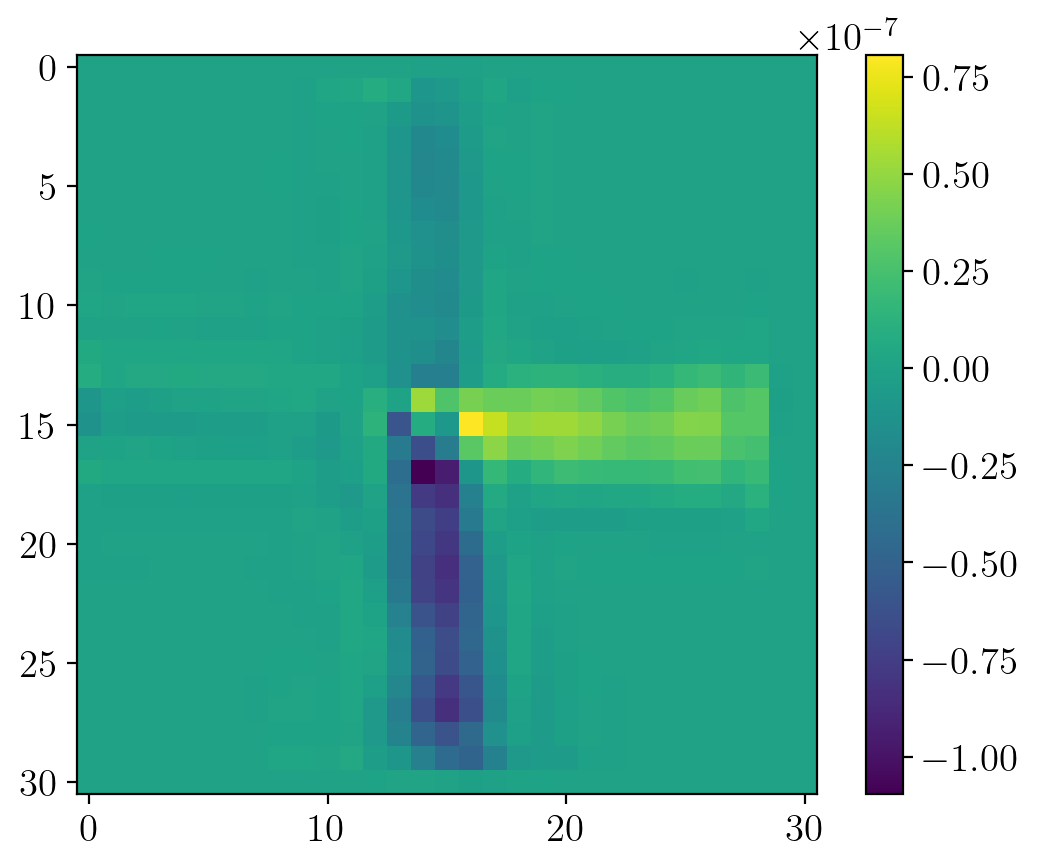

In [28]:
img = plt.imshow(lin_grad.to_numpy().reshape((31, 31)))
plt.colorbar(img)

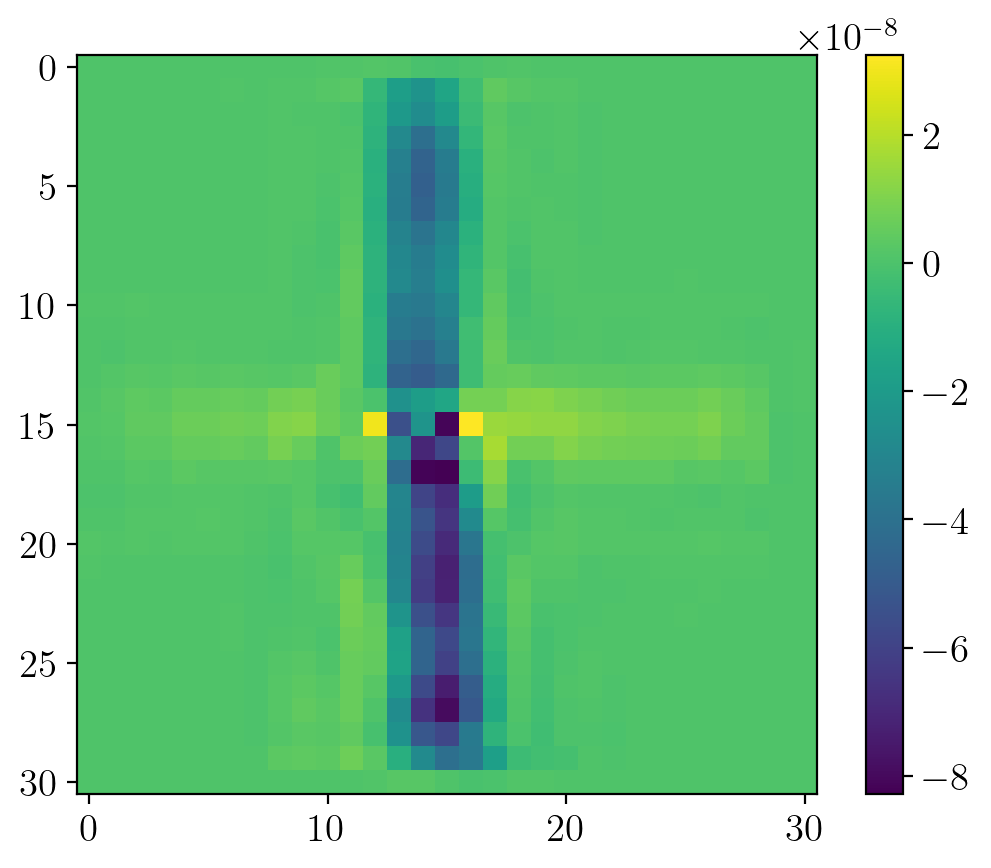

In [29]:
img = plt.imshow(lin_grad__.to_numpy().reshape((31, 31)))
plt.colorbar(img)

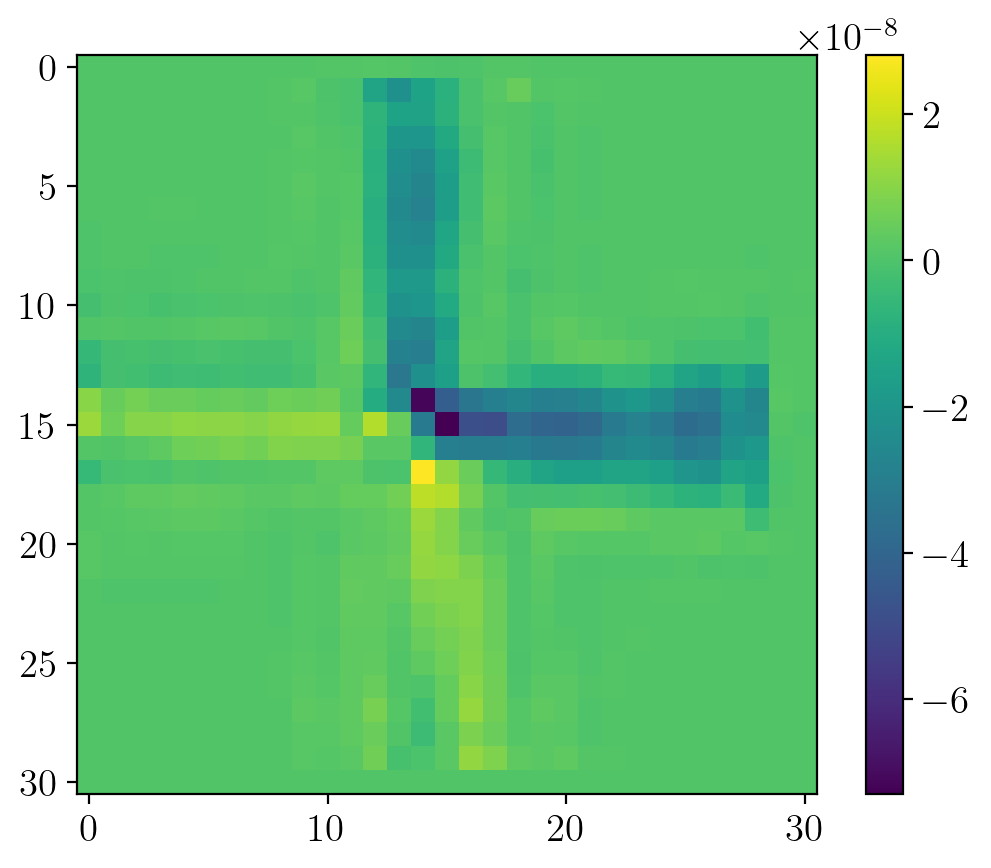

In [30]:
img = plt.imshow((lin_grad__ - lin_grad).to_numpy().reshape((31, 31)))
plt.colorbar(img)

In [31]:
diff = lin_grad__ - lin_grad
print(np.sqrt(FOM.products['prod_Q'].apply2(diff, diff))[0,0])
print(np.sqrt(FOM.products['prod_Q'].apply2(diff, diff))[0,0] / np.sqrt(FOM.products['prod_Q'].apply2(lin_grad, lin_grad))[0,0] * 100) 

2.860697299228759e-07
55.32770576674474


In [80]:
diff_q_2 = u_h - _u_r
FOM.A.material_model.save_time_series(
    [v.real_part.impl for v in diff_q_2.vectors],
    str('diff_q_2'),
    str(SAVE_PATH),
    np.linspace(FOM.T_initial, FOM.T_final, FOM.nt+1)
)

In [63]:
np.max(np.abs((u_h - _u_r).to_numpy()))

9.507602589977661e-05

In [64]:
_u_r.to_numpy()[2]

array([-8.98892359e-10,  4.19331866e-10, -7.66057276e-11, ...,
       -9.53796419e-10, -1.27834780e-09, -1.01491652e-09])

In [69]:
np.max(np.abs((u_h - _u_r).to_numpy()))

4.961117623769086e-05

In [70]:
_u_r.to_numpy()[2]

array([-4.86486416e-10,  1.86066115e-09, -7.89779426e-10, ...,
       -8.23460499e-10, -7.15098617e-10, -1.51320748e-09])

In [83]:
q = data_['q'][0]
q_ = QrVrROM.Q.make_array(reductor.project_vectorarray(q, basis='parameter_basis'))
u_r = QrVrROM.solve_state(q=q_)
_u_r_0 = reductor.reconstruct(u_r, basis='state_basis')

q = data_['q'][1]
q_ = QrVrROM.Q.make_array(reductor.project_vectorarray(q, basis='parameter_basis'))
u_r = QrVrROM.solve_state(q=q_)
_u_r_1 = reductor.reconstruct(u_r, basis='state_basis')

#q = data_['q'][2]
q = data_['q'][2]
q_ = QrVrROM.Q.make_array(reductor.project_vectorarray(q, basis='parameter_basis'))
u_r = QrVrROM.solve_state(q=q_)
_u_r_2 = reductor.reconstruct(u_r, basis='state_basis')


diff_q_12 = _u_r_1 - _u_r_2
FOM.A.material_model.save_time_series(
    [v.real_part.impl for v in diff_q_12.vectors],
    str('diff_q_12'),
    str(SAVE_PATH),
    np.linspace(FOM.T_initial, FOM.T_final, FOM.nt+1)
)

In [84]:
q = data_['q'][0]
u_h_0 = FOM.solve_state(q=q)

q = data_['q'][1]
u_h_1 = FOM.solve_state(q=q)

q = data_['q'][2]
u_h_2 = FOM.solve_state(q=q)

In [90]:
diff = data_['q'][1] - data_['q'][2]
np.sqrt(FOM.products['prod_Q'].apply2(diff, diff))

array([[3.27522838]])

In [8]:
diff_C_12 =  FOM.C.apply(_u_r_1) - FOM.C.apply(_u_r_2)

In [11]:
np.mean(np.abs(diff_C_12.to_numpy()))

1.7679999743483685e-05

In [10]:
np.mean(np.abs(diff_q_12.to_numpy()))

2.2666758606143312e-05

In [28]:
np.max(diff_2.to_numpy())

0.0010642754314198755

In [85]:
diff_0 = _u_r_0 - u_h_0
diff_1 = _u_r_1 - u_h_1 
diff_2 = _u_r_2 - u_h_2

norm_diff_1 = np.sqrt(FOM.products['prod_V'].pairwise_apply2(diff_1, diff_1))
norm_diff_2 = np.sqrt(FOM.products['prod_V'].pairwise_apply2(diff_2, diff_2))

FOM.products['prod_V'].pairwise_apply2(diff_1, diff_2) / (norm_diff_1 * norm_diff_2)

/tmp/ipykernel_30466/4254516261.py:8: RuntimeWarning: invalid value encountered in divide
  FOM.products['prod_V'].pairwise_apply2(diff_1, diff_2) / (norm_diff_1 * norm_diff_2)


array([        nan,  0.01793145, -0.01088613, -0.01074039, -0.01419264,
        0.01027127,  0.00398719,  0.05351354,  0.03329503,  0.08189288,
       -0.02269672, -0.09028315, -0.10566129, -0.13807165, -0.07471417,
        0.01318975,  0.1296333 ,  0.16118951,  0.13983845,  0.13140465,
        0.01830872, -0.05820868, -0.12224601, -0.10973176, -0.08517135,
       -0.00084886,  0.07327223,  0.08670253,  0.09164191,  0.05430034,
        0.02194408, -0.0099356 , -0.03567795, -0.03049173, -0.02647036,
       -0.00658795,  0.01187806,  0.01233567,  0.00845629,  0.00306451,
       -0.00265154, -0.00257095,  0.00248967, -0.00097679,  0.00143838,
       -0.00094216,  0.0009266 , -0.00149963, -0.00154196, -0.0061661 ,
       -0.00800762])

In [89]:
np.sqrt(FOM.products['bochner_prod_V'].apply2(diff_2, diff_2))

array([[0.07802481]])

In [77]:
np.mean(np.abs(diff_1.to_numpy()))

4.780568754087311e-08

In [72]:
np.mean(np.abs(diff_2.to_numpy()))

2.0572824713031952e-05

In [84]:
q = data_['q'][1]
u_h_1 = FOM.solve_state(q=q)

q = data_['q'][2]
u_h_2 = FOM.solve_state(q=q)

In [93]:
np.max(np.abs((u_h_1 - u_h_2).to_numpy()))

0.0002025673111075983

In [89]:
diff_u_h_12 = u_h_1 - u_h_2
FOM.A.material_model.save_time_series(
    [v.real_part.impl for v in diff_u_h_12.vectors],
    str('diff_u_h_12'),
    str(SAVE_PATH),
    np.linspace(FOM.T_initial, FOM.T_final, FOM.nt+1)
)

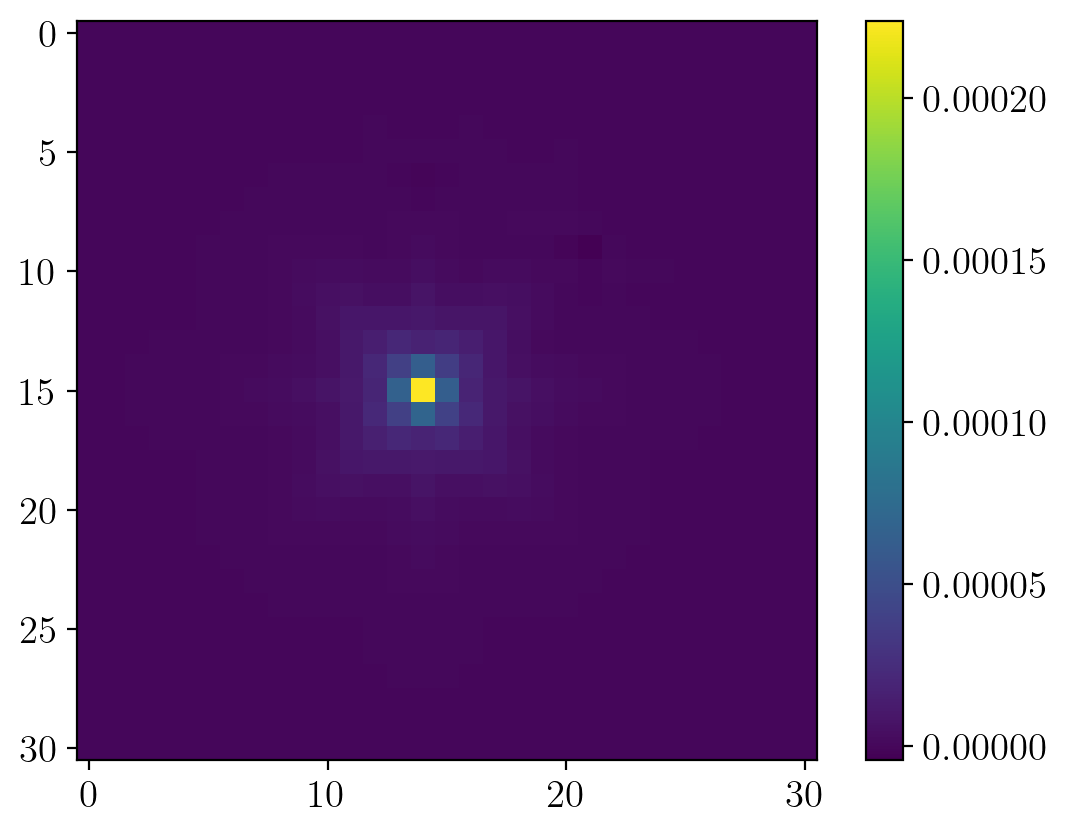

In [33]:
#plt.imshow((grad-grad__).to_numpy().reshape((31,31)))
#plt.imshow((lin_grad - lin_grad__).to_numpy().reshape((31,31)))
plt.imshow((lin_grad).to_numpy().reshape((31,31)))
plt.colorbar()

In [21]:
diff = lin_grad - lin_grad__
err_nabla_lin_J = np.sqrt(FOM.products['prod_Q'].apply2(diff, diff))[0,0]
norm_nabla_lin_J = np.sqrt(FOM.products['prod_Q'].apply2(lin_grad, lin_grad))[0,0]
rel_err_nabla_lin_J = err_nabla_lin_J / norm_nabla_lin_J
rel_err_nabla_lin_J

0.9396644920391776

In [148]:
vals = [0, 1e-2, 0.5, 1]
nabla_lin_Js = []

for val in vals:
    d = val * FOM.Q.make_array(np.ones(FOM.Q.dim)) + FOM.Q.make_array(np.random.uniform(-1e-2, 1e-2, size=(1, FOM.Q.dim)))
    #d = FOM.Q.make_array(np.zeros(FOM.Q.dim))
    
    u_h = FOM.solve_state(q=q)
    p_h = FOM.solve_adjoint(q=q, u=u_h)
    
    lin_u_h = FOM.solve_linearized_state(q=q, d=d, u=u_h)
    lin_p_h = FOM.solve_linearized_adjoint(q=q, u=u_h, lin_u=lin_u_h)

    nabla_lin_J = FOM.linearized_gradient(q=q, d=d, u=u_h, lin_p=lin_p_h)
    
    nabla_lin_Js.append(nabla_lin_J)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

In [149]:
vals = [0, 1e-2, 0.5, 1]
nabla_lin_J_rs = []

for val in vals:
    q_ = QrVrROM.Q.make_array(reductor.project_vectorarray(q, basis='parameter_basis'))
    d = val * FOM.Q.make_array(np.ones(FOM.Q.dim)) + FOM.Q.make_array(np.random.uniform(-1e-2, 1e-2, size=(1, FOM.Q.dim)))
    
    d_ = QrVrROM.Q.make_array(reductor.project_vectorarray(d, basis='parameter_basis'))
    
    u_r = QrVrROM.solve_state(q=q_)
    p_r = QrVrROM.solve_adjoint(q=q_, u=u_r)
    
    lin_u_r = QrVrROM.solve_linearized_state(q=q_, d=d_, u=u_r)
    lin_p_r = QrVrROM.solve_linearized_adjoint(q=q_, u=u_r, lin_u=lin_u_r)
    
    nabla_lin_J_r = QrVrROM.linearized_gradient(q=q_, d=d_, u=u_r, lin_p=lin_p_r)
    nabla_lin_J_r = reductor.reconstruct(nabla_lin_J_r, basis='parameter_basis')
    
    nabla_lin_J_rs.append(nabla_lin_J_r)


In [150]:
i = 0
plt.imshow((nabla_lin_Js[i] - nabla_lin_J_rs[i]).to_numpy().reshape((31,31)))
plt.colorbar()

In [152]:
errors = []
for i in range(len(nabla_lin_Js)):
    error = np.max(np.abs((nabla_lin_Js[i] - nabla_lin_J_rs[i]).to_numpy()))
    
    errors.append(error)
print(errors)

[7.781220057289304e-09, 3.1524082659241393e-09, 1.2255230000633038e-08, 2.6428024194019128e-08]


In [136]:
errors = []
for i in range(len(nabla_lin_Js)):
    error = np.max(np.abs((nabla_lin_Js[i] - nabla_lin_J_rs[i]).to_numpy()))
    
    errors.append(error)
print(errors)

[1.1361369630088917e-14, 9.385419611285055e-15, 4.301054175629652e-13, 8.166560384480128e-13]


In [153]:
import numpy as np
from scipy.sparse.linalg import LinearOperator, eigs

N_Q = FOM.Q.dim

def matvec(d_):
    d = FOM.Q.make_array(d_)
    
    u_h = FOM.solve_state(q=q)
    p_h = FOM.solve_adjoint(q=q, u=u_h)
    
    lin_u_h = FOM.solve_linearized_state(q=q, d=d, u=u_h)
    lin_p_h = FOM.solve_linearized_adjoint(q=q, u=u_h, lin_u=lin_u_h)

    nabla_lin_J = FOM.linearized_gradient(q=q, d=d, u=u_h, lin_p=lin_p_h)
    
    return nabla_lin_J

# build matrix-free operator
G_op = LinearOperator((N_Q, N_Q), matvec=matvec, dtype=float)

eigvals, eigvecs = eigs(G_op, k=5, which='LM')

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

KeyboardInterrupt: 

In [ ]:
eigvecs

In [172]:
data_ = data['new_baseline_TR_identity_time_step']
for i in range(len(data_['q'])-1):
    d_i = data_['q'][i] - data_['q'][i+1]
    print(np.sqrt(FOM.products['prod_Q'].apply2(d_i, d_i)[0,0]))

0.27072787031271717
0.473554292689096
0.3384692848750639
0.3585667093757883
0.32115839163602616
0.24254997304554954
0.48572335681415635
0.3642871566652622
0.34278707502430916
0.3059618976628502
0.3551382928184395
0.157249540404642
0.0630921700409652
0.015093555677389809


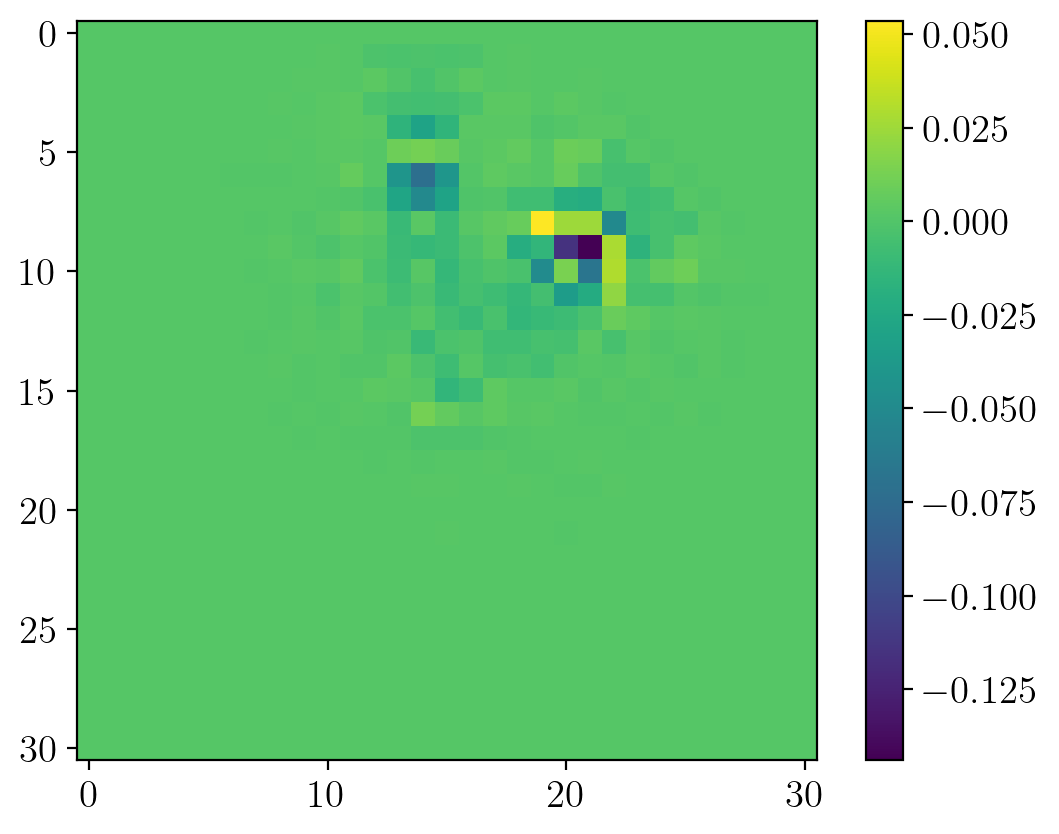

In [34]:
data_ = data['new_baseline_TR_identity_time_step']
i = 0
d_i = data_['q'][i] - data_['q'][i+1]
plt.imshow(d_i.to_numpy().reshape(31,31))
plt.colorbar()